In [1]:
import os
os.environ["NO_PROXY"] = "pypi.org,files.pythonhosted.org"
os.environ["no_proxy"] = "pypi.org,files.pythonhosted.org"

In [5]:
%pip install -q requests python-dotenv numpy pandas matplotlib pymilvus httpx langgraph langchain langchain-openai

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\Arthur\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [6]:
import re, json, time, hashlib
from pathlib import Path
import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from pymilvus import MilvusClient
from dotenv import load_dotenv
load_dotenv()

KEY = os.getenv("OPENROUTER_API_KEY")
assert KEY, "нет ключа"
BASE_URL = "https://openrouter.ai/api/v1"
CHEAP, MID, STRONG = "openai/gpt-4o-mini", "anthropic/claude-haiku-4.5", "anthropic/claude-sonnet-4.6"
DATA = Path("data")
Path("img").mkdir(exist_ok=True)

CALLS, FIRST, TAG = [], {}, {"now": "без метки"}

def on_response(response):
    response.read()
    request = json.loads(response.request.content or b"{}")
    usage = response.json().get("usage") or {}
    FIRST.setdefault(TAG["now"], request)
    CALLS.append({"tag": TAG["now"], "model": request.get("model", "?").split("/")[-1],
                  "messages": len(request.get("messages", [])), "tools": len(request.get("tools", [])),
                  "prompt": usage.get("prompt_tokens", 0), "completion": usage.get("completion_tokens", 0),
                  "cost": usage.get("cost") or 0})

HTTP = httpx.Client(event_hooks={"response": [on_response]}, timeout=180)
HEADERS = {"Authorization": f"Bearer {KEY}", "X-Title": "agents-course-hw3"}

def chat(messages, model=CHEAP, tools=None, temperature=0.0):
    body = {"model": model, "messages": messages, "temperature": temperature, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
    for attempt in range(5):
        r = HTTP.post(f"{BASE_URL}/chat/completions", json=body, headers=HEADERS)
        if r.status_code == 200:
            return r.json()["choices"][0]["message"]
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")

def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

TAG["now"] = "проверка счётчика"
chat([{"role": "user", "content": "Say OK"}])
pd.DataFrame(CALLS)

,tag,model,messages,tools,prompt,completion,cost
0,проверка счётчика,gpt-4o-mini,1,0,9,2,0.000003


In [8]:
client = MilvusClient(uri="http://localhost:19530")
print(client.list_collections())

['facts', 'course', 'lines']


In [9]:
import requests

EMBED_URL = "https://openrouter.ai/api/v1/embeddings"
EMBED_MODEL, DIM = "openai/text-embedding-3-small", 512

def post_with_retry(url, body, attempts=5):
    problem = "нет ответа"
    for attempt in range(attempts):
        try:
            r = requests.post(url, json=body, headers=HEADERS, timeout=120)
            if r.status_code == 200:
                return r.json()
            problem = f"HTTP {r.status_code}: {r.text[:200]}"
            if r.status_code not in (429, 500, 502, 503, 504):
                break
        except requests.RequestException as e:
            problem = type(e).__name__
        time.sleep(2.0 * (attempt + 1))
    raise RuntimeError(problem)

EMB = {}

def load_cache():
    for path in [DATA / "embeddings_512.npz", Path("emb_cache.npz")]:
        if path.exists():
            z = np.load(path)
            EMB.update({str(k): v.astype(np.float32) for k, v in zip(z["keys"], z["vectors"])})
    return len(EMB)

def embed_batch(texts):
    data = post_with_retry(EMBED_URL, {"model": EMBED_MODEL, "input": texts, "dimensions": DIM})
    return [row["embedding"] for row in data["data"]]

def key_of(text):
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

def embed_cached(texts):
    todo = list({t for t in texts if key_of(t) not in EMB})
    for i in range(0, len(todo), 64):
        batch = todo[i:i + 64]
        for t, v in zip(batch, embed_batch(batch)):
            EMB[key_of(t)] = np.array(v, dtype=np.float32)
    return np.array([EMB[key_of(t)] for t in texts])

print("в кэше:", load_cache())

в кэше: 10538


In [10]:
def search_milvus(name, query, k=5, flt=""):
    vec = embed_cached([query])[0]
    hits = client.search(name, data=[vec.tolist()], limit=k, filter=flt,
                          output_fields=["page", "section", "url", "text"])[0]
    return [{"id": h["id"], "score": h["distance"], **h["entity"]} for h in hits]

In [11]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

def run_tool(call):
    name = call["function"]["name"]
    try:
        spec = TOOLS[name]
        result = spec["fn"](**spec["args"].model_validate_json(call["function"]["arguments"]).model_dump())
    except Exception as e:
        result = f"ошибка инструмента {name}: {e}"
    return {"role": "tool", "tool_call_id": call["id"], "content": str(result)[:3000]}

AGENT_SYSTEM = ("You answer questions about events of 2026. Never answer from memory: look facts up with the tools, do not repeat the same call. "
                "When done, write the last line as FINAL: <short answer>, or NOT_FOUND if the knowledge base has no answer.")

def bare_agent(question, model=CHEAP, max_steps=6):
    messages, seen = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}], set()
    schemas = [t["schema"] for t in TOOLS.values()]
    for step in range(max_steps):
        msg = chat(messages, model, tools=schemas)
        messages.append(msg)
        calls = msg.get("tool_calls") or []
        keys = {(c["function"]["name"], c["function"]["arguments"]) for c in calls}
        if not calls or keys & seen or step == max_steps - 1:
            break
        seen |= keys
        messages += [run_tool(c) for c in calls]
    if calls:
        messages += [{"role": "tool", "tool_call_id": c["id"], "content": "call rejected: answer from what you already have"} for c in calls]
        msg = chat(messages, model)
    return msg.get("content") or ""

class KBArgs(BaseModel):
    query: str = Field(description="short search query in English: names, dates, key terms of the event")
    page: str = Field(default="", description="optional exact page title to search within, for example '2026 in Japan'; empty means all pages")

def knowledge_base(query: str, page: str = "") -> str:
    flt = f'page == "{page}"' if page else ""
    hits = search_milvus("lines", query, 5, flt)
    if not hits:
        return "ничего не найдено"
    return "\n".join(f"({h['page']}, {h['section']}) {h['text']}" for h in hits)

register(knowledge_base, KBArgs, "Searches the local knowledge base of 2026 events and returns the five closest facts with their page and section")

In [12]:
from concurrent.futures import ThreadPoolExecutor
from collections import Counter

NUMBERS = {w: str(n) for n, w in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    return " ".join(NUMBERS.get(w, w) for w in re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split())

def is_correct(task, answer):
    return set(norm(task["answer"]).split()) <= set(norm(answer).split())

def pmap(fn, items, workers=6):
    with ThreadPoolExecutor(workers) as ex:
        return list(ex.map(fn, items))

RESULTS = {}

def run_config(tag, fn, sample=None, workers=6):
    sample = sample or tasks
    TAG["now"] = tag
    def one(task):
        try:
            return fn(task["question"])
        except Exception as e:
            return f"ошибка: {type(e).__name__}"
    answers = pmap(one, sample, workers)
    RESULTS[tag] = [{"id": t["id"], "answer": a, "ok": is_correct(t, a)} for t, a in zip(sample, answers)]
    return report([tag])

def report(tags=None):
    rows = []
    for tag in tags or RESULTS:
        res, calls = RESULTS[tag], [c for c in CALLS if c["tag"] == tag]
        n, ok, cost = len(res), sum(r["ok"] for r in res), sum(c["cost"] for c in calls)
        rows.append({"конфигурация": tag, "верно": f"{ok}/{n}", "доля": round(ok / n, 3), "вызовов на вопрос": round(len(calls) / n, 1),
                     "токенов на вопрос": round(sum(c["prompt"] + c["completion"] for c in calls) / n),
                     "центов на вопрос": round(cost / n * 100, 4), "центов за верный": round(cost / ok * 100, 4) if ok else None})
    return pd.DataFrame(rows)

def wrong(tag, n=10):
    return pd.DataFrame([{"эталон": t["answer"], "ответ": str(r["answer"])[:110]}
                         for t, r in zip(tasks, RESULTS[tag]) if not r["ok"]][:n])

In [14]:
tasks = load_jsonl("fresh_2026.jsonl")[:40]
len(tasks), tasks[0]

(40,
 {'id': 'fresh-0',
  'source': 'fresh',
  'question': 'On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?',
  'answer': '15 March',
  'evidence': '15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022.',
  'page': '2026 in Ukraine',
  'url': 'https://en.wikipedia.org/wiki/2026_in_Ukraine',
  'agent_ok': False})

In [15]:
run_config("голый цикл, mini", bare_agent)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",35/40,0.875,2.5,974,0.0181,0.0207


In [16]:
from langchain_core.tools import StructuredTool

knowledge_base_tool = StructuredTool.from_function(
    func=knowledge_base,
    name="knowledge_base",
    description="Searches the local knowledge base of 2026 events and returns the five closest facts with their page and section",
    args_schema=KBArgs,
)
LC_TOOLS = [knowledge_base_tool]

In [17]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

LG_MIDDLEWARE = []

def lc_model(model=CHEAP, temperature=0.0):
    return ChatOpenAI(model=model, base_url=BASE_URL, api_key=KEY, http_client=HTTP, temperature=temperature)

def run_langgraph(question, model=CHEAP, temperature=0.0, extra=""):
    agent = create_agent(lc_model(model, temperature), tools=LC_TOOLS, system_prompt=AGENT_SYSTEM + extra, middleware=LG_MIDDLEWARE)
    out = agent.invoke({"messages": [{"role": "user", "content": question}]}, {"recursion_limit": 14})
    return out["messages"]

def ask_langgraph(question, model=CHEAP, temperature=0.0, extra=""):
    return run_langgraph(question, model, temperature, extra)[-1].content

In [18]:
TAG["now"] = "пустой запрос, голый цикл"
bare_agent("test")
TAG["now"] = "пустой запрос, LangGraph"
ask_langgraph("test")

import json as _json
bare_req = FIRST["пустой запрос, голый цикл"]
lg_req = FIRST["пустой запрос, LangGraph"]

print("=== голый цикл: описание инструмента в запросе ===")
print(_json.dumps(bare_req.get("tools", []), ensure_ascii=False, indent=2))
print("\n=== LangGraph: описание инструмента в запросе ===")
print(_json.dumps(lg_req.get("tools", []), ensure_ascii=False, indent=2))

pd.DataFrame([c for c in CALLS if c["tag"] in ("пустой запрос, голый цикл", "пустой запрос, LangGraph")])

langchain-openai injected a custom httpx transport to apply `http_socket_options`, which disables httpx's proxy auto-detection (system proxy configuration detected). Set `LANGCHAIN_OPENAI_TCP_KEEPALIVE=0` or pass `http_socket_options=()` to restore default proxy behavior, or supply `openai_proxy` / your own `http_client` / `http_async_client` to take full control.


=== голый цикл: описание инструмента в запросе ===
[
  {
    "type": "function",
    "function": {
      "name": "knowledge_base",
      "description": "Searches the local knowledge base of 2026 events and returns the five closest facts with their page and section",
      "parameters": {
        "properties": {
          "query": {
            "description": "short search query in English: names, dates, key terms of the event",
            "title": "Query",
            "type": "string"
          },
          "page": {
            "default": "",
            "description": "optional exact page title to search within, for example '2026 in Japan'; empty means all pages",
            "title": "Page",
            "type": "string"
          }
        },
        "required": [
          "query"
        ],
        "title": "KBArgs",
        "type": "object"
      }
    }
  }
]

=== LangGraph: описание инструмента в запросе ===
[
  {
    "type": "function",
    "function": {
      "name": "knowle

,tag,model,messages,tools,prompt,completion,cost
0,"пустой запрос, голый цикл",gpt-4o-mini,2,1,170,5,0.000029
1,"пустой запрос, LangGraph",gpt-4o-mini,2,1,160,5,0.000027


In [19]:
run_config("LangGraph, mini", ask_langgraph)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"LangGraph, mini",35/40,0.875,2.7,1074,0.0195,0.0223


In [20]:
report(["голый цикл, mini", "LangGraph, mini"])

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",35/40,0.875,2.5,974,0.0181,0.0207
1,"LangGraph, mini",35/40,0.875,2.7,1074,0.0195,0.0223


In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class QA(TypedDict):
    question: str
    answer: str
    evidence: str
    feedback: str
    rounds: int

class Verdict(BaseModel):
    supported: bool = Field(description="true only if the evidence explicitly supports the answer")
    issue: str = Field(description="what is wrong or missing, empty if supported")

CRITIC_SYSTEM = ("You check a short answer against the facts the agent retrieved from the knowledge base. Judge only by the evidence. "
                 "If the evidence does not contain the answer, the answer is not supported.")

In [22]:
def answer_node(state):
    note = ""
    if state["feedback"]:
        note = f"\n\nA reviewer rejected your previous answer '{state['answer']}': {state['feedback']} Search again and correct it."
    messages = run_langgraph(state["question"] + note)
    found = "\n".join(str(m.content) for m in messages if getattr(m, "type", "") == "tool")
    return {"answer": messages[-1].content, "evidence": found[-4000:], "rounds": state["rounds"] + 1}

def critic_node(state):
    judge = lc_model(CHEAP).with_structured_output(Verdict)
    verdict = judge.invoke([("system", CRITIC_SYSTEM),
        ("user", f"Question: {state['question']}\nAnswer: {state['answer']}\nEvidence the agent found:\n{state['evidence'] or 'nothing'}")])
    return {"feedback": "" if verdict.supported else verdict.issue}

def route(state):
    if state["feedback"] and state["rounds"] < 2:
        return "answer"
    return END

graph = StateGraph(QA)
graph.add_node("answer", answer_node)
graph.add_node("critic", critic_node)
graph.add_edge(START, "answer")
graph.add_edge("answer", "critic")
graph.add_conditional_edges("critic", route, ["answer", END])
checked = graph.compile()

def ask_checked(question):
    return checked.invoke({"question": question, "answer": "", "evidence": "", "feedback": "", "rounds": 0})["answer"]

In [23]:
run_config("LangGraph + критик, mini", ask_checked)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"LangGraph + критик, mini",36/40,0.9,3.8,1541,0.0271,0.0301


In [24]:
base, crit = RESULTS["LangGraph, mini"], RESULTS["LangGraph + критик, mini"]
fixed = sum(not b["ok"] and c["ok"] for b, c in zip(base, crit))
broken = sum(b["ok"] and not c["ok"] for b, c in zip(base, crit))
fixed, broken

(1, 0)

In [25]:
def bag(answer):
    return " ".join(sorted(norm(answer).split()))

def vote(question, k=3):
    with ThreadPoolExecutor(k) as ex:
        answers = list(ex.map(lambda _: ask_langgraph(question, CHEAP, 0.7), range(k)))
    keys = [bag(a) for a in answers]
    top, n = Counter(keys).most_common(1)[0]
    return {"answer": answers[keys.index(top)], "agreement": n / k}

ESCALATED = []

def cascade(question):
    v = vote(question, 3)
    if v["agreement"] == 1:
        return v["answer"]
    ESCALATED.append(question)
    return ask_langgraph(question, STRONG)

In [26]:
run_config("голосование-3, mini", lambda q: vote(q)["answer"], workers=4)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голосование-3, mini",35/40,0.875,7.8,3102,0.0563,0.0643


In [27]:
pd.DataFrame(CALLS)["cost"].sum()

np.float64(0.04843875)

In [28]:
run_config("каскад, mini→sonnet", cascade, workers=4)


,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"каскад, mini→sonnet",33/40,0.825,9.0,4114,0.4548,0.5513


In [29]:
len(ESCALATED)

20

In [31]:
def strong_alone(question):
    return chat([{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}], model=STRONG).get("content") or ""

run_config("сильная модель, без инструментов", strong_alone)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"сильная модель, без инструментов",7/40,0.175,1.0,361,0.4373,2.499


In [32]:
from langchain.agents.middleware import ModelCallLimitMiddleware

capped_agent = create_agent(lc_model(CHEAP), tools=LC_TOOLS, system_prompt=AGENT_SYSTEM,
                             middleware=[ModelCallLimitMiddleware(run_limit=2, exit_behavior="end")])

TAG["now"] = "бюджетный предел, демо"
hard_question = tasks[0]["question"]
out = capped_agent.invoke({"messages": [{"role": "user", "content": hard_question}]}, {"recursion_limit": 14})
print("Вопрос:", hard_question)
print("Ответ после обрезания:", out["messages"][-1].content)

Вопрос: On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?
Ответ после обрезания: Ukraine boycotted the closing ceremony of the 2026 Winter Paralympics on 15 March 2026. 

FINAL: 15 March 2026


In [33]:
capped_agent = create_agent(lc_model(CHEAP), tools=LC_TOOLS, system_prompt=AGENT_SYSTEM,
                             middleware=[ModelCallLimitMiddleware(run_limit=1, exit_behavior="end")])

TAG["now"] = "бюджетный предел, демо-1"
out = capped_agent.invoke({"messages": [{"role": "user", "content": hard_question}]}, {"recursion_limit": 14})
print("Ответ при пределе в 1 вызов:", repr(out["messages"][-1].content))

Ответ при пределе в 1 вызов: 'Model call limits exceeded: run limit (1/1)'


In [34]:
wrong("каскад, mini→sonnet", 10)

,эталон,ответ
0,Miguel Díaz-Canel,ошибка: GraphRecursionError
1,Pavel Durov,ошибка: GraphRecursionError
2,Gavin Snider,ошибка: GraphRecursionError
3,Clara and the Below,ошибка: GraphRecursionError
4,a drought,ошибка: GraphRecursionError
5,43,"Based on the knowledge base, the train derailm..."
6,Vladimir Alekseyev,ошибка: GraphRecursionError


In [35]:
from langchain.agents.middleware import wrap_model_call
from langchain_core.messages import HumanMessage

LAST_STEP = "You have no more tool calls left. Answer now with what you have, or say NOT_FOUND."

@wrap_model_call
def last_step_without_tools(request, handler):
    if sum(m.type == 'ai' for m in request.messages) >= 5:
        request = request.override(tools=[], messages=request.messages + [HumanMessage(LAST_STEP)])
    return handler(request)

LG_MIDDLEWARE.append(last_step_without_tools)

In [36]:
run_config("каскад, mini→sonnet (фикс)", cascade, workers=4)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"каскад, mini→sonnet (фикс)",37/40,0.925,8.9,4050,0.5502,0.5949


In [37]:
for tag in ["LangGraph, mini", "LangGraph + критик, mini", "голосование-3, mini"]:
    n_err = sum("ошибка" in str(r["answer"]) for r in RESULTS[tag])
    print(tag, "— ошибок:", n_err)

LangGraph, mini — ошибок: 4
LangGraph + критик, mini — ошибок: 2
голосование-3, mini — ошибок: 3


In [42]:
run_config("голосование-3, mini (финал)", lambda q: vote(q)["answer"], workers=4)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голосование-3, mini (финал)",34/40,0.85,7.5,2807,0.0523,0.0616


In [43]:
run_config("LangGraph, mini (v2)", ask_langgraph)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"LangGraph, mini (v2)",36/40,0.9,2.6,975,0.0181,0.0201


In [44]:
run_config("LangGraph + критик, mini (v2)", ask_checked)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"LangGraph + критик, mini (v2)",35/40,0.875,4.3,1764,0.0313,0.0358


In [45]:
base2, crit2 = RESULTS["LangGraph, mini (v2)"], RESULTS["LangGraph + критик, mini (v2)"]
fixed2 = sum(not b["ok"] and c["ok"] for b, c in zip(base2, crit2))
broken2 = sum(b["ok"] and not c["ok"] for b, c in zip(base2, crit2))
fixed2, broken2

(0, 1)

In [46]:
COLORS = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}

def color_of(tag):
    if "каскад" in tag:
        return COLORS["red"]
    if "сильная модель" in tag:
        return COLORS["violet"]
    if "голосование" in tag:
        return COLORS["yellow"]
    if "критик" in tag:
        return COLORS["aqua"]
    if "LangGraph" in tag:
        return COLORS["orange"]
    return COLORS["blue"]

def money_chart(tags, path, title):
    table = report(tags)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.set_xscale("log")
    for _, r in table.iterrows():
        ax.scatter(r["центов на вопрос"], r["доля"] * 100, s=120, color=color_of(r["конфигурация"]),
                    zorder=3, edgecolors="white", linewidths=0.8)
    ax.margins(x=0.2, y=0.12)
    fig.canvas.draw()
    placed = []
    for _, r in table.sort_values("центов на вопрос").iterrows():
        for dx, dy in [(10, 6), (10, -14), (-10, 6), (-10, -14), (10, 20), (10, -28)]:
            label = ax.annotate(r["конфигурация"], (r["центов на вопрос"], r["доля"] * 100), xytext=(dx, dy),
                                 textcoords="offset points", fontsize=9, ha="left" if dx > 0 else "right", color="#0b0b0b")
            box = label.get_window_extent()
            if not any(box.overlaps(b) for b in placed) or dy == -28:
                break
            label.remove()
        placed.append(box)
    ax.set_xlabel("цена вопроса, центы (логарифмическая шкала)")
    ax.set_ylabel("доля верных, %")
    ax.set_title(title)
    ax.grid(alpha=0.3, color="#e1e0d9")
    ax.spines[["top", "right"]].set_visible(False)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return table

In [ ]:
FINAL_TAGS = ["голый цикл, mini", "LangGraph, mini (v2)", "LangGraph + критик, mini (v2)",
              "голосование-3, mini (финал)", "каскад, mini→sonnet (фикс)", "сильная модель, без инструментов"]

In [48]:
def run_config(tag, fn, sample=None, workers=6):
    CALLS[:] = [c for c in CALLS if c["tag"] != tag]  # на случай повторного запуска той же конфигурации
    sample = sample or tasks
    TAG["now"] = tag
    def one(task):
        try:
            return fn(task["question"])
        except Exception as e:
            return f"ошибка: {type(e).__name__}"
    answers = pmap(one, sample, workers)
    RESULTS[tag] = [{"id": t["id"], "answer": a, "ok": is_correct(t, a)} for t, a in zip(sample, answers)]
    return report([tag])

In [49]:
run_config("голый цикл, mini", bare_agent)

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",36/40,0.9,2.5,981,0.0183,0.0203


,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",36/40,0.900,2.5,981,0.0183,0.0203
1,"LangGraph, mini (v2)",36/40,0.900,2.6,975,0.0181,0.0201
2,"LangGraph + критик, mini (v2)",35/40,0.875,4.3,1764,0.0313,0.0358
3,"голосование-3, mini (финал)",34/40,0.850,7.5,2807,0.0523,0.0616
4,"каскад, mini→sonnet (фикс)",37/40,0.925,8.9,4050,0.5502,0.5949
5,"сильная модель, без инструментов",7/40,0.175,1.0,361,0.4373,2.4990


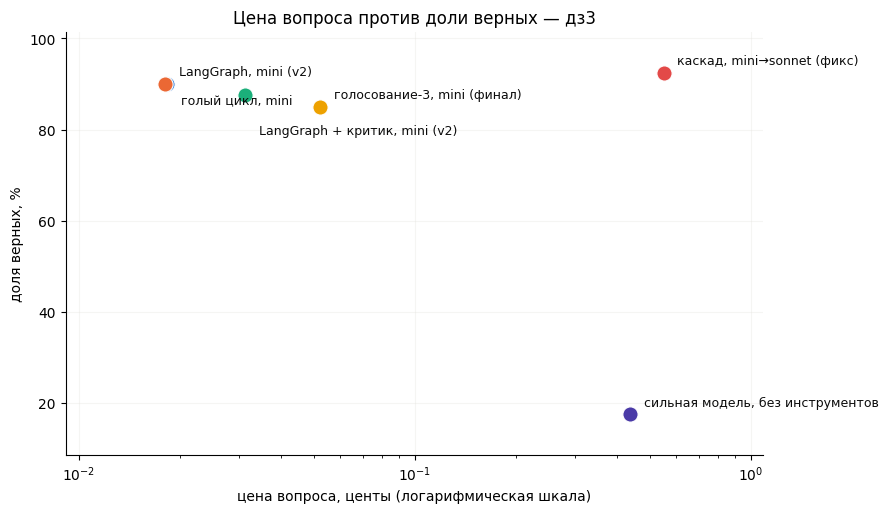

In [50]:
money_chart(FINAL_TAGS, "img/money_hw3.png", "Цена вопроса против доли верных — дз3")